# MouthVideoCNN model overview
This project builds a video-based speaker identification system using a simplified deep learning pipeline. The goal is to determine who is speaking based on visual information of mouth movement extracted from video clips.

---
### Data pipeline
Each training example is created as follows:

- A video clip is loaded from the dataset
- A fixed number of frames are sampled across the clip
- A face is detected in each frame
- A rough mouth region of interest is cropped
- Each ROI is resized to a consistent size (e.g., 64x64 grayscale)

### Feature extraction
Each frame is processed independently by a CNN

- The CNN extracts spatial features from the mouth region
- Each frame is converted into a feature vector (e.g., size 128)

### Temporal Aggregation / Averaging
To combine information across frames: 

- The model computes the average of all frame feature vectors
- Produces a single feature representation for the entire video

### Classification
The aggregated feature vector is passed through a linear layer that:

- Maps features to speaker classes
- Outputs class scores for each speaker

Training uses:

- Cross-Entropy loss
- Accuracy for evaluation

### Training process

- Dataset is split into training and validation sets
- The model is trained over a fixed number of epochs
- Each epoch:
    - Processes batches of video samples
    - Updates model weights using backpropagation
- Validation performance is tracked to measure generalization

### Evaluation
At the end of training, the model performs a lightweight evaluation and logging step:

- The model is run on the validation set to compute final loss and accuracy
- A random validation sample is selected
- The model generates a prediction for that sample
- The following are displayed:
    - Video path
    - Predicted speaker ID
    - Correct speaker ID
    - Sampled ROI frames used for the prediction

### Model and Results Saving
At the end of the notebook:

- The trained model is saved as a `.pt` file, which includes:
    - Model weights
    - Optimizer state
    - Training configuration
- A corresponding `.txt` file is saved alongside it containing:
    - Dataset information (train/validation size, number of classes)
    - Hyperparameters (epochs, batch size, learning rate, etc.)
    - Final validation metrics

The filename includes a timestamp to ensure each run is uniquely recorded and reproducible.

# Change Log Overview
See detailed change logs at the end of this notebook.

### V6
V6 introduced comparison training for the ResNet-18 model.
- Swapped data processing from grayscale to RGB.
- Added checkpoint saving option for best F1 score.
- Swapped optimizer for both to AdamW.
- Added additional data augmentation.

### V5
V5 consisted of a batch of minor tweaks to fine-tune the model as well as the addition to F1 Scoring metrics.

### V4
Reworked the mouth ROI pipeline and data-loading flow.
- Added MediaPipe Face Landmarker setup and automatic model download
- Replaced Haar-cascade face detection with landmark-based mouth cropping
- Added local ROI caching so extracted mouth tensors can be reused
- Moved augmentation into the dataset pipeline and loaded cached tensors during training
- Reworked dataset splitting and label mapping around explicit train/validation row lists
- Expanded debugging with mouth-ROI visualization and cache-load checks

### V3
Improved training management and result retention.
- Added automatic checkpoint saving based on best validation loss
- Tracked best-epoch metrics separately from final-epoch metrics
- Updated training summary output to report best checkpoint results
- Extended training further to allow scheduled learning-rate reductions to take effect

### V2
- Replaced averaging with GRU
- Increased frame count from 8 to 16
- Increased epoch count from 5 to 20
- Added data augmentation (rotation & brightness)
- Introduced LR scheduler

### V1
Baseline video speaker-identification model.
- Sampled mouth-region frames from each video
- Processed each frame with a 2D CNN
- Averaged frame features over time
- Used a simple training loop with final model/result saving

# Imports
---
## V4 changes:
- Added mediapipe imports

In [21]:
from pathlib import Path
import csv
import random

import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from datetime import datetime
import matplotlib.pyplot as plt

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import os
import urllib.request
import shutil

from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassF1Score,
    MulticlassConfusionMatrix,
)

# Config

In [22]:
# Should we retrain our local model?
RETRAIN_LOCAL = True
RETRAIN_RESNET = False

# Model information
MODEL_NAME = "video_cnn_V6"
SAVE_DIR = Path("saved_models")
SAVE_DIR.mkdir(exist_ok=True)

# Path to the CSV file with all the samples
CSV_PATH = Path("./vox_celeb_subset/subset.csv")
# Root folder that contains the subset
DATA_ROOT = Path("./vox_celeb_subset/")

# Timestamp at start of the training for filenames
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# Saving information for the model
model_filename = f"{MODEL_NAME}_{timestamp}.pt"
model_save_path = SAVE_DIR / model_filename

# Saving information for the final readout
txt_filename = f"{MODEL_NAME}_{timestamp}.txt"
txt_path = SAVE_DIR / txt_filename

# Saving information for ResNet-18
RESNET_NAME = f"resnet18_baseline_{MODEL_NAME}"
resnet_filename = f"{RESNET_NAME}_{timestamp}.pt"
resnet_save_path = SAVE_DIR / resnet_filename

# Information for the MediaPipeline model
FLM_MODEL_DIR = "./facedetection_model"
FLM_MODEL_PATH = os.path.join(FLM_MODEL_DIR, "face_landmarker.task")

# Frames to sample in each vid
NUM_FRAMES = 32
# W/H of cropped mouth images
IMG_SIZE = 64
# Samples used in one training step
BATCH_SIZE = 8
# How many passes through training
EPOCHS = 40
# LR for optimizer
LR = 1e-3
# Patience for changing LR
LR_PAT = 1
# Weight decay
WEIGHT_DECAY = 1e-4
# Early stopping
EARLY_STOP_PATIENCE = 8
MIN_EPOCHS = 12
# Seed for reproducing
SEED = 611

# Save the ROI data locally
# Force a fresh cache when extraction logic changes
REBUILD_CACHE = False
CACHE_VERSION = f"mediapipe_image_frames-{NUM_FRAMES}_size-{IMG_SIZE}_seed-{SEED}"
ROI_CACHE_DIR = Path(f"./roi_cache/{CACHE_VERSION}")

if REBUILD_CACHE and ROI_CACHE_DIR.exists():
    shutil.rmtree(ROI_CACHE_DIR)

ROI_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Use GPU if possible
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Const results based on seed
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Device: cuda


# Load rows from subset.csv

In [23]:
def fix_path(path_str):
    """
    Convert path txt from CSV into an obj
    """
    # Remove windwos slashes and replace with forward slashes
    path_str = path_str.replace("\\", "/")
    return Path(path_str)

# Read every row from the CSV into a list
rows = []
with open(CSV_PATH, newline="", encoding="utf-8-sig") as f:
    reader = csv.DictReader(f)
    for row in reader:
        rows.append(row)

print("Total rows:", len(rows))
print("Columns:", rows[0].keys())
print("Example:", rows[0])

Total rows: 1200
Columns: dict_keys(['speaker_id', 'label', 'aac_path', 'mp4_path'])
Example: {'speaker_id': 'id01671', 'label': '0', 'aac_path': 'aac\\id01671\\7eBNBYBi3dU\\00007.m4a', 'mp4_path': 'mp4\\id01671\\7eBNBYBi3dU\\00007.mp4'}


# Mediapipe Face Landmarker setup

In [24]:
# Official MediaPipe model URL (Face Landmarker)
FLM_MODEL_URL = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/latest/face_landmarker.task"

def download_model_if_needed():
    os.makedirs(FLM_MODEL_DIR, exist_ok=True)

    if os.path.exists(FLM_MODEL_PATH):
        print(f"Model already exists at: {FLM_MODEL_PATH}")
        return

    print("Downloading MediaPipe Face Landmarker model...")
    urllib.request.urlretrieve(FLM_MODEL_URL, FLM_MODEL_PATH)
    print(f"Model saved to: {FLM_MODEL_PATH}")

download_model_if_needed()

FACE_LANDMARKER_MODEL_PATH = FLM_MODEL_PATH

# Padding around the mouth box
MOUTH_PAD_X = 0.15   # 15% extra width on each side
MOUTH_PAD_Y = 0.20   # 20% extra height above/below

# If a detected mouth crop is too small, ignore it and fall back
MIN_MOUTH_BOX_PX = 10

# Use IMAGE mode, not VIDEO mode, because we sample independent frames
BaseOptions = python.BaseOptions
FaceLandmarker = vision.FaceLandmarker
FaceLandmarkerOptions = vision.FaceLandmarkerOptions
VisionRunningMode = vision.RunningMode

landmarker_options = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=FACE_LANDMARKER_MODEL_PATH),
    running_mode=VisionRunningMode.IMAGE,
    num_faces=1,
    min_face_detection_confidence=0.5,
    min_face_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)

face_landmarker = FaceLandmarker.create_from_options(landmarker_options)

Model already exists at: ./facedetection_model\face_landmarker.task


# ROI Landmark helpers

In [25]:
# A practical set of outer + inner lip landmarks from the 468-point face mesh topology.
# We use both so the crop covers the full mouth area more reliably.
MOUTH_LANDMARKS = sorted(set([
    # Outer lips
    61, 146, 91, 181, 84, 17, 314, 405, 321, 375, 291,
    # Inner lips
    78, 95, 88, 178, 87, 14, 317, 402, 318, 324, 308,
    # Upper/lower center support points
    13, 14, 0, 17
]))

def clamp(val, low, high):
    return max(low, min(val, high))

def mouth_box_from_landmarks(face_landmarks, frame_w, frame_h, pad_x=0.15, pad_y=0.20):
    """
    Convert MediaPipe normalized mouth landmarks into a padded pixel box.
    Returns (x1, y1, x2, y2) or None if invalid.
    """
    xs = []
    ys = []

    for idx in MOUTH_LANDMARKS:
        lm = face_landmarks[idx]
        xs.append(lm.x * frame_w)
        ys.append(lm.y * frame_h)

    x1 = min(xs)
    x2 = max(xs)
    y1 = min(ys)
    y2 = max(ys)

    w = x2 - x1
    h = y2 - y1

    if w < MIN_MOUTH_BOX_PX or h < MIN_MOUTH_BOX_PX:
        return None

    # Add padding
    x1 -= pad_x * w
    x2 += pad_x * w
    y1 -= pad_y * h
    y2 += pad_y * h

    # Clamp to image bounds
    x1 = int(clamp(round(x1), 0, frame_w - 1))
    y1 = int(clamp(round(y1), 0, frame_h - 1))
    x2 = int(clamp(round(x2), 1, frame_w))
    y2 = int(clamp(round(y2), 1, frame_h))

    if x2 <= x1 or y2 <= y1:
        return None

    return x1, y1, x2, y2

# ROI Extractor Helpers

In [26]:
def cache_exists(cache_dir):
    if not cache_dir.exists():
        return False
    # Check if it has at least one cached file
    return any(cache_dir.iterdir())


def build_cache_name(row):
    """
    Create a stable cache filename for each video.
    """
    rel_path = fix_path(row["mp4_path"])
    safe_name = str(rel_path).replace("\\", "_").replace("/", "_")
    return ROI_CACHE_DIR / f"{safe_name}.pt"


def extract_roi_sequence(video_path, num_frames=8, img_size=64):
    """
    Read a video and return a sequence of mouth-region images

    Output shape: [T, 3, H, W]
    """
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    if fps is None or fps <= 0:
        fps = 25.0

    if total_frames <= 0:
        indices = list(range(num_frames))
    else:
        indices = np.linspace(0, total_frames - 1, num_frames).astype(int)

    sequence = []
    last_good = np.zeros((img_size, img_size, 3), dtype=np.uint8)

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ok, frame = cap.read()

        if not ok:
            sequence.append(last_good.copy())
            continue

        frame_h, frame_w = frame.shape[:2]
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)

        try:
            result = face_landmarker.detect(mp_image)
        except Exception:
            sequence.append(last_good.copy())
            continue

        if result.face_landmarks and len(result.face_landmarks) > 0:
            face_landmarks = result.face_landmarks[0]

            mouth_box = mouth_box_from_landmarks(
                face_landmarks,
                frame_w,
                frame_h,
                pad_x=MOUTH_PAD_X,
                pad_y=MOUTH_PAD_Y
            )

            if mouth_box is not None:
                x1, y1, x2, y2 = mouth_box
                roi = frame_rgb[y1:y2, x1:x2]

                if roi.size > 0:
                    roi = cv2.resize(roi, (img_size, img_size), interpolation=cv2.INTER_AREA)
                    last_good = roi
                    sequence.append(roi)
                    continue

        sequence.append(last_good.copy())

    cap.release()

    # [T, H, W, 3] -> [T, 3, H, W], scaled to [0, 1]
    sequence = np.stack(sequence).astype(np.float32) / 255.0
    sequence = torch.from_numpy(sequence).permute(0, 3, 1, 2)

    return sequence


def precompute_roi_cache(rows, data_root, num_frames=16, img_size=64):
    """
    Build ROI tensors once and save them to disk.
    """
    built = 0
    skipped = 0

    for i, row in enumerate(rows):
        cache_path = build_cache_name(row)

        if cache_path.exists():
            skipped += 1
            continue

        mp4_path = data_root / fix_path(row["mp4_path"])

        try:
            frames = extract_roi_sequence(
                mp4_path,
                num_frames=num_frames,
                img_size=img_size
            )
            torch.save(frames, cache_path)
            built += 1
        except Exception as e:
            print(f"Failed on {mp4_path}: {e}")

        if (i + 1) % 100 == 0:
            print(f"Processed {i + 1}/{len(rows)} videos")

    print(f"Built: {built}")
    print(f"Skipped existing: {skipped}")


# Rebuild our cache
if REBUILD_CACHE:
    print("Rebuilding cache...")
    precompute_roi_cache(rows, DATA_ROOT, num_frames=NUM_FRAMES, img_size=IMG_SIZE)
else:
    if not cache_exists(ROI_CACHE_DIR):
        print("Cache not found. Forcing rebuild...")
        precompute_roi_cache(rows, DATA_ROOT, num_frames=NUM_FRAMES, img_size=IMG_SIZE)
    else:
        print("Using existing cache.")

Using existing cache.


In [27]:
def show_mouth_debug(video_path, frame_index=None):
    cap = cv2.VideoCapture(str(video_path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if frame_index is None:
        frame_index = max(0, total_frames // 2)

    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_index))
    ok, frame = cap.read()
    cap.release()

    if not ok:
        print("Could not read frame.")
        return

    frame_h, frame_w = frame.shape[:2]
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)

    # IMAGE mode call
    result = face_landmarker.detect(mp_image)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(frame_rgb)
    plt.title("Original frame")
    plt.axis("off")

    plt.subplot(1, 2, 2)

    if result.face_landmarks and len(result.face_landmarks) > 0:
        mouth_box = mouth_box_from_landmarks(
            result.face_landmarks[0],
            frame_w,
            frame_h,
            pad_x=MOUTH_PAD_X,
            pad_y=MOUTH_PAD_Y
        )

        if mouth_box is not None:
            x1, y1, x2, y2 = mouth_box
            roi = frame_rgb[y1:y2, x1:x2]
            plt.imshow(roi)
            plt.title("Detected mouth ROI (RGB)")
        else:
            plt.text(0.5, 0.5, "Mouth box invalid", ha="center", va="center")
            plt.title("Debug")
    else:
        plt.text(0.5, 0.5, "No face landmarks found", ha="center", va="center")
        plt.title("Debug")

    plt.axis("off")
    plt.tight_layout()
    plt.show()

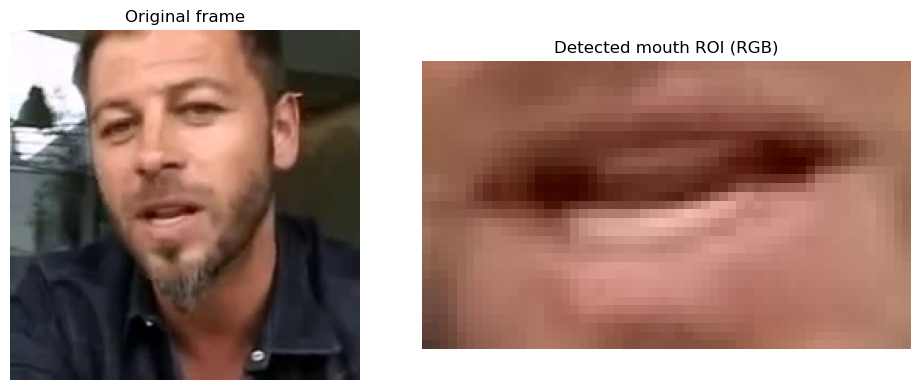

Sequence shape: torch.Size([32, 3, 64, 64])


In [28]:
face_landmarker = FaceLandmarker.create_from_options(landmarker_options)

# Example: test a single sample before training
sample_row = rows[0]
sample_video = DATA_ROOT / fix_path(sample_row["mp4_path"])

show_mouth_debug(sample_video)

frames = extract_roi_sequence(sample_video, num_frames=NUM_FRAMES, img_size=IMG_SIZE)
print("Sequence shape:", frames.shape)   # Expect [T, 3, 64, 64]

# Dataset

In [29]:
class VideoROIDataset(Dataset):
    def __init__(self, rows, data_root, label_to_idx, idx_to_label, training=False):
        """
        Make the custom dataset
    
        Each item returns:
            frames = tensor of shape [T, 3, H, W]
            label  = integer class index
        """
        self.rows = rows
        self.data_root = data_root
        self.training = training
        self.label_to_idx = label_to_idx
        self.idx_to_label = idx_to_label
        self.label_to_speaker = {int(r["label"]): r["speaker_id"] for r in rows}

    def __len__(self):
        return len(self.rows)

    def apply_augmentation(self, frames):
        frames = frames.clone()

        if random.random() < 0.5:
            frames = torch.flip(frames, dims=[3])

        brightness_scale = 0.8 + 0.4 * random.random()
        frames = torch.clamp(frames * brightness_scale, 0.0, 1.0)

        return frames

    def __getitem__(self, idx):
        row = self.rows[idx]
        label = self.label_to_idx[int(row["label"])]

        cache_path = build_cache_name(row)
        frames = torch.load(cache_path)

        if self.training:
            frames = self.apply_augmentation(frames)

        return frames, torch.tensor(label, dtype=torch.long)


indices = list(range(len(rows)))
random.Random(SEED).shuffle(indices)

train_size = int(0.8 * len(rows))
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_rows = [rows[i] for i in train_indices]
val_rows = [rows[i] for i in val_indices]

labels = sorted({int(r["label"]) for r in rows})
label_to_idx = {label: i for i, label in enumerate(labels)}
idx_to_label = {i: label for label, i in label_to_idx.items()}

train_ds = VideoROIDataset(train_rows, DATA_ROOT, label_to_idx, idx_to_label, training=True)
val_ds = VideoROIDataset(val_rows, DATA_ROOT, label_to_idx, idx_to_label, training=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Train size:", len(train_ds))
print("Val size:", len(val_ds))
print("Classes:", len(label_to_idx))

Train size: 960
Val size: 240
Classes: 60


# Model

In [30]:
class MouthVideoCNN(nn.Module):
    """
    First iteration of the baseline model

    Notes:
        - Not a 3D CNN, instead process each frame with a 2D CNN
        - Then, avg out the frame features over time to classify
    """
    def __init__(self, num_classes):
        super().__init__()

        # Extract features from one frame at a time
        self.frame_encoder = nn.Sequential(
            # Input = [3, 64, 64]
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1),
            # [32, 32, 32]
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1),
            # [64, 16, 16]
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1),
            # Reduce each map to a single value
            # [128, 1, 1]
            nn.AdaptiveMaxPool2d((1, 1)),
        )

        # Reads frame freatures in order and builds memory of the sequence allowing the model to learn motion
        self.gru = nn.GRU(
            input_size=128,
            hidden_size=256,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.4)
        
        # Final classifier layer
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        """
        Input shape: x = [B, T, 3, H, W]
        B = batch size
        T = num of frames
        3 = RGB channel
        H, W = img size
        """
        # Save original shape pieces
        b, t, c, h, w = x.shape

        # Combine batch and time so the CNN can process frames individually
        x = x.view(b * t, c, h, w)

        # Encode every frame
        x = self.frame_encoder(x)

        # Remove the last two size-1 dimensions
        x = x.view(b, t, 128)

        # Pass sequence of frame features into GRU
        # _, h_n = self.gru(x)
        gru_out, h_n = self.gru(x)
        
        # h_n contains the final hidden state (summary of sequence)
        # x = h_n[-1]
        x = gru_out.mean(dim=1)

        # Run dropout layer
        x = self.dropout(x)

        # Classify
        x = self.fc(x)
        
        return x

# Create model
model = MouthVideoCNN(num_classes=len(label_to_idx)).to(device)

# Standard classification loss
criterion = nn.CrossEntropyLoss()

# Adam optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Reduce LR when validation loss stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",        # we want to minimize validation loss
    factor=0.5,        # cut LR in half
    patience=LR_PAT    # wait X epochs before reducing
)

# Other metrics to track
val_acc_metric = MulticlassAccuracy(num_classes=len(label_to_idx)).to(device)
val_macro_f1_metric = MulticlassF1Score(num_classes=len(label_to_idx), average="macro").to(device)
val_weighted_f1_metric = MulticlassF1Score(num_classes=len(label_to_idx), average="weighted").to(device)
val_confmat_metric = MulticlassConfusionMatrix(num_classes=len(label_to_idx)).to(device)
val_top3_metric = MulticlassAccuracy(num_classes=len(label_to_idx), top_k=3).to(device)

print(model)

MouthVideoCNN(
  (frame_encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.1)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.1)
    (11): AdaptiveMaxPool2d(output_size=(1, 1))
  )
  (gru): GRU(128, 256, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_f

# Find any errors within our cache

In [31]:
sample_size = 128

picked = random.sample(rows, min(sample_size, len(rows)))
blank_videos = 0
blank_frames = 0

for row in picked:
    frames = torch.load(build_cache_name(row), weights_only=True)
    zero_mask = frames.sum(dim=(1,2,3)) == 0
    blank_frames += int(zero_mask.sum().item())
    blank_videos += int(bool(zero_mask.all()))

print("Audited videos:", len(picked))
print("Completely blank videos:", blank_videos)
print("Blank frames total:", blank_frames)

Audited videos: 128
Completely blank videos: 1
Blank frames total: 33


# Training Loop

In [32]:
# Track metrics across epochs
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
val_macro_f1s = []
val_weighted_f1s = []

# Keep track of the best validation result seen so far
best_val_loss = float("inf")
best_val_acc = -1.0
best_epoch = 0

# Keep the matching training metrics from that same epoch
best_train_loss = None
best_train_acc = None
best_val_macro_f1 = -1
best_val_weighted_f1 = None

epochs_without_improve = 0

def run_epoch(loader, train=True):
    """
    Run one full pass through a dataloader
    """
    if train:
        model.train()
    else:
        model.eval()
        val_acc_metric.reset()
        val_macro_f1_metric.reset()
        val_weighted_f1_metric.reset()
        val_confmat_metric.reset()

    total_loss = 0.0
    total_correct = 0
    total = 0

    for frames, labels in loader:
        # Move data to CPU or GPU
        frames = frames.to(device)
        labels = labels.to(device)

        # Clear old grads before training
        if train:
            optimizer.zero_grad()

        # Only compute gradients during training
        with torch.set_grad_enabled(train):
            # FWD pass
            outputs = model(frames)

            # Compute loss
            loss = criterion(outputs, labels)

            # Backprop + weight update in training mode
            if train:
                loss.backward()
                optimizer.step()

        # Prediced class = index of largest output score
        preds = outputs.argmax(dim=1)

        # Accumulate totals for avg loss and accuracy
        total_loss += loss.item() * labels.size(0)
        total_correct += (preds == labels).sum().item()
        total += labels.size(0)

        # Update only in validation mode
        if not train:
            val_acc_metric.update(outputs, labels)
            val_macro_f1_metric.update(outputs, labels)
            val_weighted_f1_metric.update(outputs, labels)
            val_confmat_metric.update(outputs, labels)

    if not train:
        val_acc = val_acc_metric.compute().item()
        val_macro_f1 = val_macro_f1_metric.compute().item()
        val_weighted_f1 = val_weighted_f1_metric.compute().item()
        val_confmat = val_confmat_metric.compute().cpu()
        return total_loss / total, val_acc, val_macro_f1, val_weighted_f1, val_confmat
    
    train_acc = total_correct / total
    return total_loss / total, total_correct / total


# Call training if marked to do so
if RETRAIN_LOCAL:
    # Main training loop
    for epoch in range(EPOCHS):
        train_loss, train_acc = run_epoch(train_loader, train=True)
        val_loss, val_acc, val_macro_f1, val_weighted_f1, val_confmat = run_epoch(val_loader, train=False)
    
        # Store values
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        val_macro_f1s.append(val_macro_f1)
        val_weighted_f1s.append(val_weighted_f1)
    
        # Check scheduler to adjust LR if needed
        prev_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(val_loss)
        curr_lr = optimizer.param_groups[0]["lr"]
    
        print(
            f"Epoch {epoch+1}/{EPOCHS} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc*100:.2f}% | "
            f"val_loss={val_loss:.4f} val_acc={val_acc*100:.2f}% | "
            f"val_macro_f1={val_macro_f1*100:.2f}% val_weighted_f1={val_weighted_f1*100:.2f}%"
        )
    
        # Tell us if the LR has changed
        if curr_lr != prev_lr:
            print(f"LR Reduced: {prev_lr:.6f} -> {curr_lr:.6f}")
    
        improved = (
            (val_acc > best_val_acc) or
            (val_acc == best_val_acc and val_macro_f1 > best_val_macro_f1) or
            (val_acc == best_val_acc and val_macro_f1 == best_val_macro_f1 and val_loss < best_val_loss)
        )
    
        # Save best checkpoint whenever validation loss improves & check for early stop
        if improved:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_train_loss = train_loss
            best_train_acc = train_acc
            best_val_macro_f1 = val_macro_f1
            best_val_weighted_f1 = val_weighted_f1
            best_val_confmat = val_confmat.clone()
            epochs_without_improve = 0
    
            torch.save({
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_val_acc": best_val_acc,
                "best_val_loss": best_val_loss,
                "best_val_macro_f1": best_val_macro_f1,
                "best_val_weighted_f1": best_val_weighted_f1,
                "train_losses": train_losses,
                "val_losses": val_losses,
                "train_accuracies": train_accuracies,
                "val_accuracies": val_accuracies,
                "val_macro_f1s": val_macro_f1s,
                "val_weighted_f1s": val_weighted_f1s,
                "num_frames": NUM_FRAMES,
                "epochs": EPOCHS,
                "learning_rate": LR,
                "image_size": IMG_SIZE,
                "batch_size": BATCH_SIZE,
            }, model_save_path)
    
            print("--> Saved new best checkpoint.")
        else:
            epochs_without_improve += 1
    
        if epoch + 1 >= MIN_EPOCHS and epochs_without_improve >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break
# Load existing model
else:
    matches = sorted(
        SAVE_DIR.glob(f"{MODEL_NAME}*.pt"),
        key=lambda p: p.stat().st_mtime,
        reverse=True
    )

    if not matches:
        raise FileNotFoundError(
            f"No checkpoint found matching {MODEL_NAME}*.pt in {SAVE_DIR.resolve()}"
        )

    model_save_path = matches[0]
    print(f"Loading latest local model from: {model_save_path}")

    checkpoint = torch.load(model_save_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])

    if "optimizer_state_dict" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    if "scheduler_state_dict" in checkpoint:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    best_val_acc = checkpoint.get("best_val_acc", None)
    best_val_loss = checkpoint.get("best_val_loss", None)
    best_val_macro_f1 = checkpoint.get("best_val_macro_f1", None)
    best_val_weighted_f1 = checkpoint.get("best_val_weighted_f1", None)

    # restore history for plotting
    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])
    train_accuracies = checkpoint.get("train_accuracies", [])
    val_accuracies = checkpoint.get("val_accuracies", [])
    val_macro_f1s = checkpoint.get("val_macro_f1s", [])
    val_weighted_f1s = checkpoint.get("val_weighted_f1s", [])

    print("Local model loaded.")

C:\Users\Austin\AppData\Local\Temp\ipykernel_10980\1321899772.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  frames = torch.load(cache_path)


Epoch 1/40 | train_loss=4.2357 train_acc=3.23% | val_loss=3.9038 val_acc=5.54% | val_macro_f1=0.50% val_weighted_f1=0.40%
--> Saved new best checkpoint.
Epoch 2/40 | train_loss=3.7891 train_acc=6.56% | val_loss=3.5967 val_acc=16.29% | val_macro_f1=8.69% val_weighted_f1=9.58%
--> Saved new best checkpoint.
Epoch 3/40 | train_loss=3.4865 train_acc=11.98% | val_loss=3.6673 val_acc=10.20% | val_macro_f1=4.80% val_weighted_f1=4.91%
Epoch 4/40 | train_loss=3.2419 train_acc=16.04% | val_loss=3.1302 val_acc=26.63% | val_macro_f1=18.96% val_weighted_f1=19.70%
--> Saved new best checkpoint.
Epoch 5/40 | train_loss=3.0186 train_acc=23.65% | val_loss=3.1845 val_acc=20.14% | val_macro_f1=14.83% val_weighted_f1=14.01%
Epoch 6/40 | train_loss=2.8692 train_acc=26.25% | val_loss=2.7750 val_acc=29.61% | val_macro_f1=22.15% val_weighted_f1=19.51%
--> Saved new best checkpoint.
Epoch 7/40 | train_loss=2.6899 train_acc=27.81% | val_loss=2.6042 val_acc=39.10% | val_macro_f1=31.56% val_weighted_f1=30.78%
-->

# Training Results

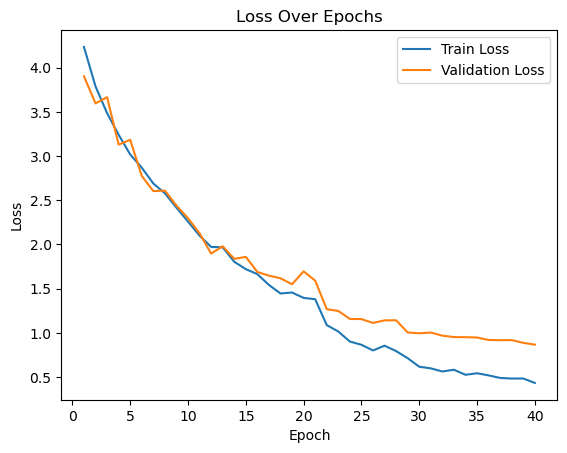

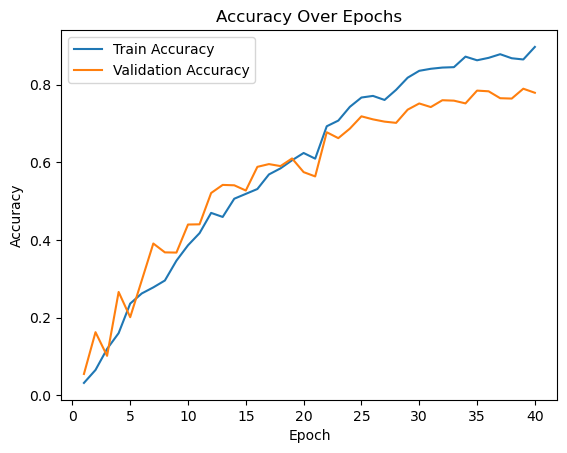

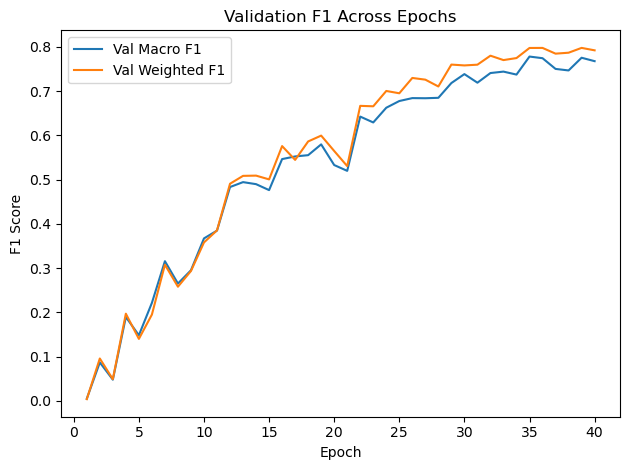

In [33]:
num_epochs_ran = len(train_losses)
epochs = range(1, num_epochs_ran + 1)

# Loss Plot
plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Over Epochs")
plt.legend()
plt.show()

# Accuracy Plot
plt.figure()
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Over Epochs")
plt.legend()
plt.show()

# F1 Plot
plt.figure()
plt.plot(range(1, len(val_macro_f1s) + 1), val_macro_f1s, label="Val Macro F1")
plt.plot(range(1, len(val_weighted_f1s) + 1), val_weighted_f1s, label="Val Weighted F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Validation F1 Across Epochs")
plt.legend()
plt.tight_layout()
plt.show()

# Sample Check

C:\Users\Austin\AppData\Local\Temp\ipykernel_10980\1321899772.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  frames = torch.load(cache_path)


=== ASSUMED SPEAKER ===
Video path: mp4\id01840\1eVJLW-WbUg\00019.mp4
Predicted speaker: id01840


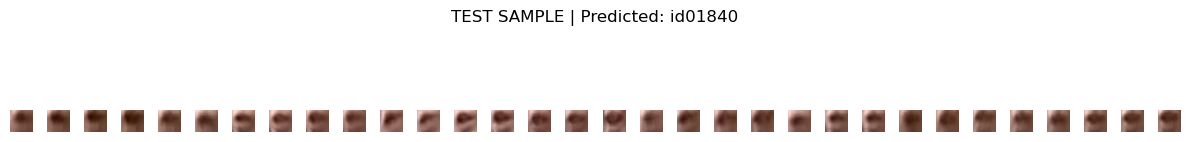


=== CORRECT SPEAKER ===
Reference path: mp4\id01840\1eVJLW-WbUg\00014.mp4
Correct Speaker: id01840


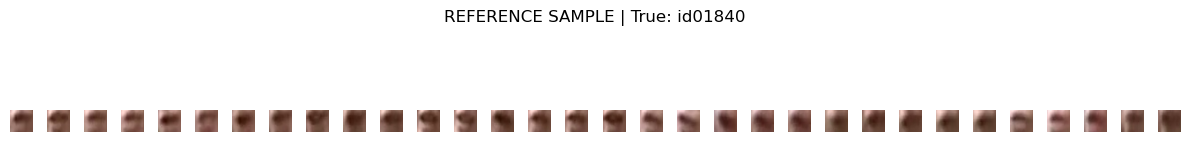

In [34]:
model.eval()

rand_idx = random.randrange(len(val_ds))
frames, label = val_ds[rand_idx]

row = val_ds.rows[rand_idx]

true_mapped = label.item()
true_original = val_ds.idx_to_label[true_mapped]
true_speaker = val_ds.label_to_speaker[true_original]

input_tensor = frames.unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(input_tensor)
    pred_mapped = outputs.argmax(dim=1).item()

pred_original = val_ds.idx_to_label[pred_mapped]
pred_speaker = val_ds.label_to_speaker[pred_original]

print("=== ASSUMED SPEAKER ===")
print(f"Video path: {row['mp4_path']}")
print(f"Predicted speaker: {pred_speaker}")

plt.figure(figsize=(12, 2))
for i in range(frames.shape[0]):
    plt.subplot(1, frames.shape[0], i + 1)
    img = frames[i].permute(1, 2, 0).cpu().numpy()   # [3,H,W] -> [H,W,3]
    plt.imshow(img.clip(0, 1))
    plt.axis("off")

plt.suptitle(f"TEST SAMPLE | Predicted: {pred_speaker}")
plt.tight_layout()
plt.show()

candidate_indices = [
    i for i, r in enumerate(val_ds.rows)
    if r["speaker_id"] == true_speaker and i != rand_idx
]

if len(candidate_indices) > 0:
    ref_idx = random.choice(candidate_indices)
    ref_frames, _ = val_ds[ref_idx]
    ref_row = val_ds.rows[ref_idx]

    print("\n=== CORRECT SPEAKER ===")
    print(f"Reference path: {ref_row['mp4_path']}")
    print(f"Correct Speaker: {true_speaker}")

    plt.figure(figsize=(12, 2))
    for i in range(ref_frames.shape[0]):
        plt.subplot(1, ref_frames.shape[0], i + 1)
        img = ref_frames[i].permute(1, 2, 0).cpu().numpy()   # [3,H,W] -> [H,W,3]
        plt.imshow(img.clip(0, 1))
        plt.axis("off")

    plt.suptitle(f"REFERENCE SAMPLE | True: {true_speaker}")
    plt.tight_layout()
    plt.show()

# Save Training Data

In [35]:
# Only save data if we are retraining / training a new model
if RETRAIN_LOCAL:
    lines = []
    
    lines.append("=== MODEL TRAINING SUMMARY ===")
    
    # Basic info
    lines.append(f"Model Name: {MODEL_NAME}")
    lines.append(f"Timestamp: {timestamp}")
    lines.append(f"Device: {device}\n")
    
    # Dataset info
    lines.append("---- DATASET ----")
    lines.append(f"Train size: {len(train_ds)}")
    lines.append(f"Validation size: {len(val_ds)}")
    lines.append(f"Num classes: {len(label_to_idx)}\n")
    
    # Hyperparameters
    lines.append("---- HYPERPARAMETERS ----")
    lines.append(f"Epochs: {EPOCHS}")
    lines.append(f"Batch size: {BATCH_SIZE}")
    lines.append(f"Learning rate: {LR}")
    lines.append(f"Frames per sample: {NUM_FRAMES}")
    lines.append(f"Image size: {IMG_SIZE}\n")
    
    # Best checkpoint info
    lines.append("---- BEST CHECKPOINT METRICS ----")
    lines.append(f"Best Epoch: {best_epoch}")
    lines.append(f"Best Train Loss: {best_train_loss:.4f}")
    lines.append(f"Best Train Accuracy: {best_train_acc*100:.4f}")
    lines.append(f"Best Validation Loss: {best_val_loss:.4f}")
    lines.append(f"Best Validation Accuracy: {best_val_acc*100:.4f}")
    lines.append(f"Best Validation Macro F1: {best_val_macro_f1*100:.4f}")
    lines.append(f"Best Validation Weighted F1: {best_val_weighted_f1*100:.4f}\n")
    
    # Full final performance
    lines.append("---- FINAL FULL METRICS ----")
    lines.append(f"Train Loss: {train_loss:.4f}")
    lines.append(f"Train Accuracy: {train_acc*100:.4f}")
    lines.append(f"Validation Loss: {val_loss:.4f}")
    lines.append(f"Validation Accuracy: {val_acc*100:.4f}\n")
    lines.append(f"Validation Macro F1: {val_macro_f1*100:.4f}")
    lines.append(f"Validation Weighted F1: {val_weighted_f1*100:.4f}\n")
    
    # History of progress
    lines.append("---- FULL TRAINING HISTORY ----")
    lines.append(f"Train Losses: {train_losses}")
    lines.append(f"Val Losses: {val_losses}")
    lines.append(f"Train Accuracies: {train_accuracies}")
    lines.append(f"Val Accuracies: {val_accuracies}\n")
    
    # Model structure
    lines.append("---- MODEL ARCHITECTURE ----")
    lines.append(str(model))
    
    with open(txt_path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))
    
    print(f"Training info saved to: {txt_path}\n")

Training info saved to: saved_models\video_cnn_V6_2026-05-05_11-49-46.txt



# Baseline model: ResNet-18
# Training

In [36]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

class MouthVideoResNet18(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
        backbone.fc = nn.Identity()   # output: 512 features per frame
        self.frame_encoder = backbone

        self.gru = nn.GRU(
            input_size=512,
            hidden_size=256,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(512, num_classes)

        # ResNet-18 pretrained normalization
        self.register_buffer(
            "mean",
            torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(1, 1, 3, 1, 1)
        )
        self.register_buffer(
            "std",
            torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(1, 1, 3, 1, 1)
        )

    def forward(self, x):
        # x: [B, T, 3, H, W]
        b, t, c, h, w = x.shape

        # normalize for pretrained weights
        x = (x - self.mean) / self.std

        # frame-by-frame ResNet
        x = x.view(b * t, 3, h, w)
        x = self.frame_encoder(x)      # [B*T, 512]
        x = x.view(b, t, 512)          # [B, T, 512]

        # temporal modeling
        x, _ = self.gru(x)
        x = x.mean(dim=1)

        x = self.dropout(x)
        x = self.fc(x)
        return x

In [37]:
model = MouthVideoResNet18(num_classes=len(label_to_idx)).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=LR_PAT
)

for p in model.frame_encoder.parameters():
    p.requires_grad = False

In [38]:
# Track metrics across epochs
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
val_macro_f1s = []
val_weighted_f1s = []

# Keep track of the best validation result seen so far
best_val_loss = float("inf")
best_val_acc = -1.0
best_epoch = 0

# Keep the matching training metrics from that same epoch
best_train_loss = None
best_train_acc = None
best_val_macro_f1 = -1
best_val_weighted_f1 = None

epochs_without_improve = 0

def run_epoch(loader, train=True):
    """
    Run one full pass through a dataloader
    """
    if train:
        model.train()
    else:
        model.eval()
        val_acc_metric.reset()
        val_macro_f1_metric.reset()
        val_weighted_f1_metric.reset()
        val_confmat_metric.reset()

    total_loss = 0.0
    total_correct = 0
    total = 0

    for frames, labels in loader:
        # Move data to CPU or GPU
        frames = frames.to(device)
        labels = labels.to(device)

        # Clear old grads before training
        if train:
            optimizer.zero_grad()

        # Only compute gradients during training
        with torch.set_grad_enabled(train):
            # FWD pass
            outputs = model(frames)

            # Compute loss
            loss = criterion(outputs, labels)

            # Backprop + weight update in training mode
            if train:
                loss.backward()
                optimizer.step()

        # Prediced class = index of largest output score
        preds = outputs.argmax(dim=1)

        # Accumulate totals for avg loss and accuracy
        total_loss += loss.item() * labels.size(0)
        total_correct += (preds == labels).sum().item()
        total += labels.size(0)

        # Update only in validation mode
        if not train:
            val_acc_metric.update(outputs, labels)
            val_macro_f1_metric.update(outputs, labels)
            val_weighted_f1_metric.update(outputs, labels)
            val_confmat_metric.update(outputs, labels)

    if not train:
        val_acc = val_acc_metric.compute().item()
        val_macro_f1 = val_macro_f1_metric.compute().item()
        val_weighted_f1 = val_weighted_f1_metric.compute().item()
        val_confmat = val_confmat_metric.compute().cpu()
        return total_loss / total, val_acc, val_macro_f1, val_weighted_f1, val_confmat
    
    train_acc = total_correct / total
    return total_loss / total, total_correct / total

if RETRAIN_RESNET:
    # Main training loop
    for epoch in range(EPOCHS):
        train_loss, train_acc = run_epoch(train_loader, train=True)
        val_loss, val_acc, val_macro_f1, val_weighted_f1, val_confmat = run_epoch(val_loader, train=False)
    
        # Store values
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        val_macro_f1s.append(val_macro_f1)
        val_weighted_f1s.append(val_weighted_f1)
    
        # Check scheduler to adjust LR if needed
        prev_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(val_loss)
        curr_lr = optimizer.param_groups[0]["lr"]
    
        print(
            f"Epoch {epoch+1}/{EPOCHS} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc*100:.2f}% | "
            f"val_loss={val_loss:.4f} val_acc={val_acc*100:.2f}% | "
            f"val_macro_f1={val_macro_f1*100:.2f}% val_weighted_f1={val_weighted_f1*100:.2f}%"
        )
    
        # Tell us if the LR has changed
        if curr_lr != prev_lr:
            print(f"LR Reduced: {prev_lr:.6f} -> {curr_lr:.6f}")
    
        improved = (
            (val_acc > best_val_acc) or
            (val_acc == best_val_acc and val_macro_f1 > best_val_macro_f1) or
            (val_acc == best_val_acc and val_macro_f1 == best_val_macro_f1 and val_loss < best_val_loss)
        )
    
        # Save best checkpoint whenever validation loss improves & check for early stop
        if improved:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_train_loss = train_loss
            best_train_acc = train_acc
            best_val_macro_f1 = val_macro_f1
            best_val_weighted_f1 = val_weighted_f1
            best_val_confmat = val_confmat.clone()
            epochs_without_improve = 0
    
            torch.save({
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_val_acc": best_val_acc,
                "best_val_loss": best_val_loss,
                "best_val_macro_f1": best_val_macro_f1,
                "best_val_weighted_f1": best_val_weighted_f1,
                "train_losses": train_losses,
                "val_losses": val_losses,
                "train_accuracies": train_accuracies,
                "val_accuracies": val_accuracies,
                "val_macro_f1s": val_macro_f1s,
                "val_weighted_f1s": val_weighted_f1s,
                "num_frames": NUM_FRAMES,
                "epochs": EPOCHS,
                "learning_rate": LR,
                "image_size": IMG_SIZE,
                "batch_size": BATCH_SIZE,
            }, resnet_save_path)
    
            print("--> Saved new best checkpoint.")
        else:
            epochs_without_improve += 1
    
        if epoch + 1 >= MIN_EPOCHS and epochs_without_improve >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break
# Load existing model
else:
    matches = sorted(
        SAVE_DIR.glob(f"{RESNET_NAME}*.pt"),
        key=lambda p: p.stat().st_mtime,
        reverse=True
    )

    if not matches:
        raise FileNotFoundError(
            f"No checkpoint found matching {RESNET_NAME}*.pt in {SAVE_DIR.resolve()}"
        )

    model_save_path = matches[0]
    print(f"Loading latest local baseline model from: {model_save_path}")

    checkpoint = torch.load(model_save_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])

    if "optimizer_state_dict" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    if "scheduler_state_dict" in checkpoint:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    best_val_acc = checkpoint.get("best_val_acc", None)
    best_val_loss = checkpoint.get("best_val_loss", None)
    best_val_macro_f1 = checkpoint.get("best_val_macro_f1", None)
    best_val_weighted_f1 = checkpoint.get("best_val_weighted_f1", None)

    # restore history for plotting
    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])
    train_accuracies = checkpoint.get("train_accuracies", [])
    val_accuracies = checkpoint.get("val_accuracies", [])
    val_macro_f1s = checkpoint.get("val_macro_f1s", [])
    val_weighted_f1s = checkpoint.get("val_weighted_f1s", [])

    print("Local model loaded.")

Loading latest local baseline model from: saved_models\resnet18_baseline_video_cnn_V6_1_2026-05-05_02-10-15.pt
Local model loaded.


C:\Users\Austin\AppData\Local\Temp\ipykernel_10980\2916036778.py:179: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_save_path, map_location=dev

# ResNet-18 Results

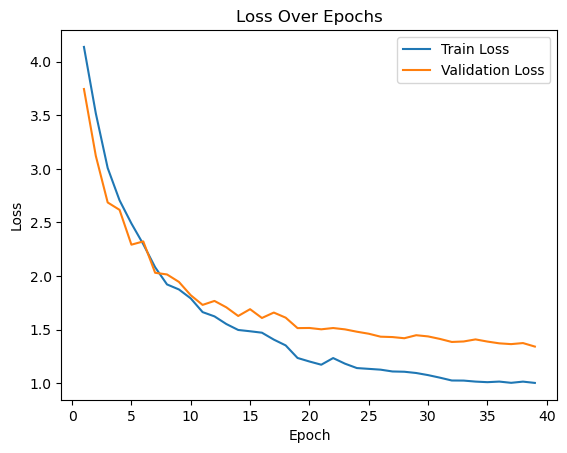

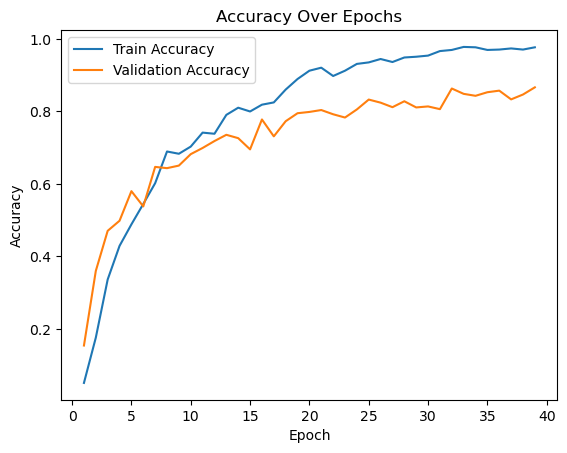

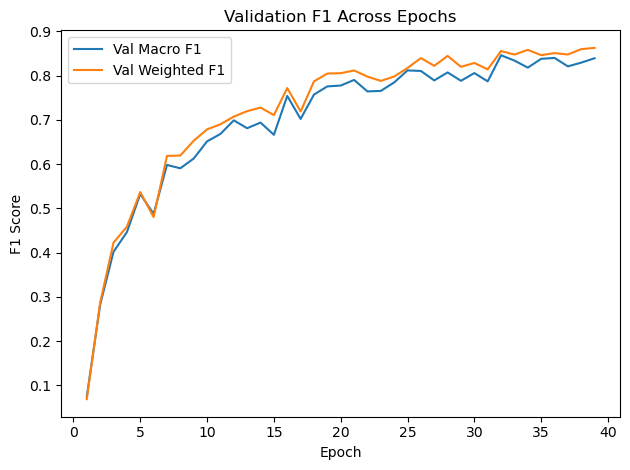

In [39]:
num_epochs_ran = len(train_losses)
epochs = range(1, num_epochs_ran + 1)

# Loss Plot
plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Over Epochs")
plt.legend()
plt.show()

# Accuracy Plot
plt.figure()
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Over Epochs")
plt.legend()
plt.show()

# F1 Plot
plt.figure()
plt.plot(range(1, len(val_macro_f1s) + 1), val_macro_f1s, label="Val Macro F1")
plt.plot(range(1, len(val_weighted_f1s) + 1), val_weighted_f1s, label="Val Weighted F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Validation F1 Across Epochs")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\Austin\AppData\Local\Temp\ipykernel_10980\1321899772.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  frames = torch.load(cache_path)


=== ASSUMED SPEAKER ===
Video path: mp4\id07983\CobLeDG5ebA\00016.mp4
Predicted speaker: id07983


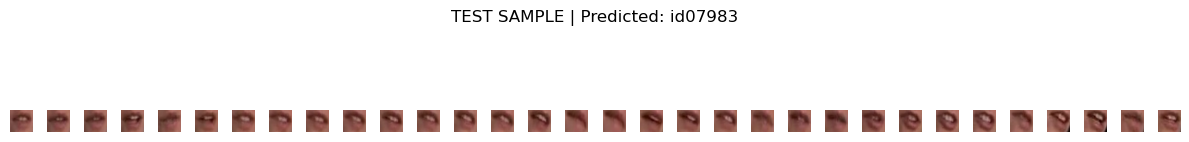


=== CORRECT SPEAKER ===
Reference path: mp4\id07983\0RPM96XQa6Q\00007.mp4
Correct Speaker: id07983


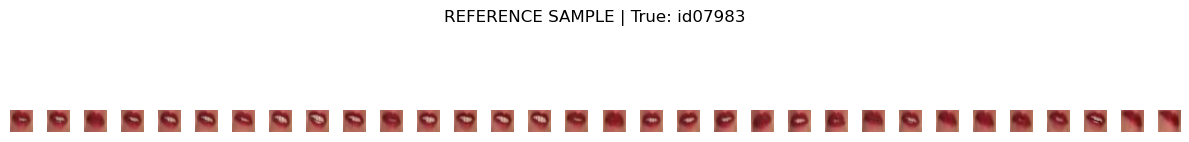

In [40]:
model.eval()

rand_idx = random.randrange(len(val_ds))
frames, label = val_ds[rand_idx]

row = val_ds.rows[rand_idx]

true_mapped = label.item()
true_original = val_ds.idx_to_label[true_mapped]
true_speaker = val_ds.label_to_speaker[true_original]

input_tensor = frames.unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(input_tensor)
    pred_mapped = outputs.argmax(dim=1).item()

pred_original = val_ds.idx_to_label[pred_mapped]
pred_speaker = val_ds.label_to_speaker[pred_original]

print("=== ASSUMED SPEAKER ===")
print(f"Video path: {row['mp4_path']}")
print(f"Predicted speaker: {pred_speaker}")

plt.figure(figsize=(12, 2))
for i in range(frames.shape[0]):
    plt.subplot(1, frames.shape[0], i + 1)
    img = frames[i].permute(1, 2, 0).cpu().numpy()   # [3,H,W] -> [H,W,3]
    plt.imshow(img.clip(0, 1))
    plt.axis("off")

plt.suptitle(f"TEST SAMPLE | Predicted: {pred_speaker}")
plt.tight_layout()
plt.show()

candidate_indices = [
    i for i, r in enumerate(val_ds.rows)
    if r["speaker_id"] == true_speaker and i != rand_idx
]

if len(candidate_indices) > 0:
    ref_idx = random.choice(candidate_indices)
    ref_frames, _ = val_ds[ref_idx]
    ref_row = val_ds.rows[ref_idx]

    print("\n=== CORRECT SPEAKER ===")
    print(f"Reference path: {ref_row['mp4_path']}")
    print(f"Correct Speaker: {true_speaker}")

    plt.figure(figsize=(12, 2))
    for i in range(ref_frames.shape[0]):
        plt.subplot(1, ref_frames.shape[0], i + 1)
        img = ref_frames[i].permute(1, 2, 0).cpu().numpy()   # [3,H,W] -> [H,W,3]
        plt.imshow(img.clip(0, 1))
        plt.axis("off")

    plt.suptitle(f"REFERENCE SAMPLE | True: {true_speaker}")
    plt.tight_layout()
    plt.show()

# Detailed Change Logs

# V5 Change log
## Model Sub-Version log
### a
- GRU hidden size increased from 128 to 256
- Final Classifier size increased from 128 to 256
### b
- Replace last hidden state with temporal mean pooling
### c
- Increased frame count from 16 to 24
### d
- Increased frame count from 24 to 32
  - Found diminishing returns. Essentially the same results as 24 frames.
  - 24: 66% val acc | 32: 67% val acc
### e
- Add bidirectional setting to GRU
### f
- Changed image size from 64 to 88
### g
- Reduced image size to 72 after results showed:
  - 64 = ~77% val acc | 88 = ~72%
### h
-  Reduced image size back to 64 after results showed:
  - 64 = ~77% val acc | 88 = ~72% | 72 = ~75%
### i
- Added additional metrics to measure F1 score
- Changed dropout to 0.4

# V4 Change log
V4 is primarily a data-pipeline rewrite.

### Detection pipeline rewrite
V3 used OpenCV's built-in Haar cascade to detect a full face, then estimated the mouth by cropping the lower-center part of the detected face rectangle. That made V3 lightweight, but the mouth crop depended on a rough face-box heuristic.

V4 replaces that approach with MediaPipe Face Landmarker. Instead of using a face rectangle, V4 defines a mouth region from a selected set of lip landmarks, expands that region with padding, clamps it to image bounds, and resizes the result into the training ROI.

Practical impact:
- More direct mouth localization
- Better control over crop shape and padding
- Less reliance on a rough lower-face guess

### Added model-asset setup for MediaPipe
V4 adds a dedicated setup block for the MediaPipe face landmarker model. The notebook now creates a models directory, checks whether the `.task` file already exists, and downloads it automatically if needed.

Practical impact:
- Removes a manual setup step
- Makes the notebook more self-contained

### ROI caching
V4 adds a cache directory, a stable cache-file naming function, and a `precompute_roi_cache(...)` pass that writes each ROI tensor to disk as a `.pt` file. The dataset is then changed to load those cached tensors instead of decoding the original video every time a sample is requested.

Practical impact:
- Greatly reduces repeated preprocessing during training
- Makes ROI generation separable from model training
- Makes bad crops easier to inspect directly from cache

### Augmentation moved out of extraction
Augmentation moved into the dataset and applied only when `training=True`.

Practical impact:
- Keeps validation samples clean
- Separates preprocessing from augmentation
- Makes evaluation behavior easier to reason about

### Dataset split and label-handling refactor
V3 used `random_split(...)` over a single dataset object. V4 switches to a seeded shuffle of row indices, then builds explicit `train_rows` and `val_rows`. It also passes label maps directly into the dataset.

Practical impact:
- Gives more control over split behavior
- Makes train/validation row access simpler in debug code
- Makes speaker/sample lookup easier in the sample-check section

### Debugging and inspection additions
V4 adds a mouth-debug visualization helper, a cache-load timing check, and a more detailed sample-check section that compares the predicted speaker sample against another validation sample from the same speaker.

Practical impact:
- Easier to verify that crops are actually showing mouths
- Easier to detect cache or mapping issues
- Better support for visual debugging during notebook development

# V3 Change Log
V3 focuses on training control, checkpointing, and more reliable experiment reporting.

---
### Checkpointing
- Replaced one-time final model saving with automatic checkpoint saving during training
- Saved the best model whenever validation loss improved

Desired effect:
- Preserve the strongest model from the run
- Avoid relying on the final epoch if later epochs perform worse

### Best-metric tracking
- Added explicit tracking for:
  - Best validation loss
  - Best validation accuracy
  - Best epoch
  - Matching training metrics at the best checkpoint

Desired effect:
- Separate “best model” results from “last epoch” results
- Make summaries more verbose

### Training summary update
- Updated the text summary output to report best-checkpoint metrics
- Kept final-epoch metrics for reference
- Continued saving full metric histories

Desired effect:
- Ensure saved results reflect the checkpoint actually retained
- Make experiment outputs easier to interpret later

### Extended training
- Increased training length further to give the scheduler time to act
- Continued training after learning-rate reductions

Observed effect:
- Validation performance improved significantly after later scheduler steps
- Best model occurred before the final epoch, confirming that checkpoint-based saving was necessary and useful

# V2 Change Log
### Temporal Modeling with GRU
In V1, frame features were averaged which removed temporal imformation.
Within V2, a GRU (Gated Recurrent Unit) replaces the feature averaging:

- Frame features are now processed sequentially instead of being collapsed / averaged
- The model learns how mouth shapes change over time

Desired effect:

- Captures mouth patterns in speech
- Improves the model's ability to distinguise speakers based on dynamics rather than static appearance

### Learning Rate Scheduler
Added a LR scheduler to modify the model's learning rate during training based on the validation loss

### Data Augmentation
V1 did not have any data augmentation, which has now been addressed:

- Random horizontal flipping of ROI images
- Small brightness variations

Desired effect:

- Reduce overfitting
- Improve robustness to visual variation

### Increased Frame Sampling
The number of sampled frames per video has been increased

Desired effect:

- Provide more temporal context
- Give the GRU more information to learn from

### Addition of Loss & Accuracy Plots
Before training loops begin, we now store and track each point for loss and accuracy, allowing us to chart our results.
This is also now reflected within the final saved model and report.